# Synthetic Population: Win-Rate Matrix in the Infinite-Sample Limit

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit

## Synthetic population

Sample utilities  for  voters and  candidates from a standard normal.
Voters are weighted uniformly.

In [25]:
M = 10  # candidates
N = 10  # voters
beta = 1.0
rng = np.random.default_rng(42)

utilities = rng.standard_normal((N, M))   # shape (N, M)
voter_dist = np.ones(N, dtype=float) / N  # uniform

avg_utilities = voter_dist @ utilities    # shape (M,)
true_ranking  = np.argsort(-avg_utilities)

print("utilities shape:", utilities.shape)
print("avg_utilities:", np.round(avg_utilities, 3))
print("true ranking (best to worst):", true_ranking)

utilities shape: (10, 10)
avg_utilities: [ 0.234 -0.24  -0.214  0.163 -0.368 -0.128 -0.106 -0.132  0.263  0.025]
true ranking (best to worst): [8 0 3 9 6 5 7 2 1 4]


## Win-rate matrix: infinite-sample limit

Under the Bradley-Terry model with inverse temperature , the probability that
candidate  beats candidate  in a comparison drawn from voter  is
. Averaging over voters gives the population win-rate:

431617P[i,j] = \sum_v w_v \,\sigma\!\left(\beta(u_{vi}-u_{vj})\right)431617

This is the matrix an empirical win-rate matrix converges to as the number of
pairwise samples grows to infinity.

In [26]:
def win_rate_matrix(utilities, voter_dist, beta=1.0):
    V, C = utilities.shape
    P = np.zeros((C, C), dtype=float)
    for v, u in enumerate(utilities):
        diffs = u[:, None] - u[None, :]   # (C, C)
        P += voter_dist[v] * expit(beta * diffs)
    np.fill_diagonal(P, 0.5)
    return P


P = win_rate_matrix(utilities, voter_dist, beta=beta)

print("P shape:", P.shape)
print("row sums (should all be ~M/2 = 5.0):", np.round(P.sum(axis=1), 3))

P shape: (10, 10)
row sums (should all be ~M/2 = 5.0): [5.558 4.594 4.65  5.442 4.365 4.839 4.891 4.81  5.704 5.146]


## Visualisation

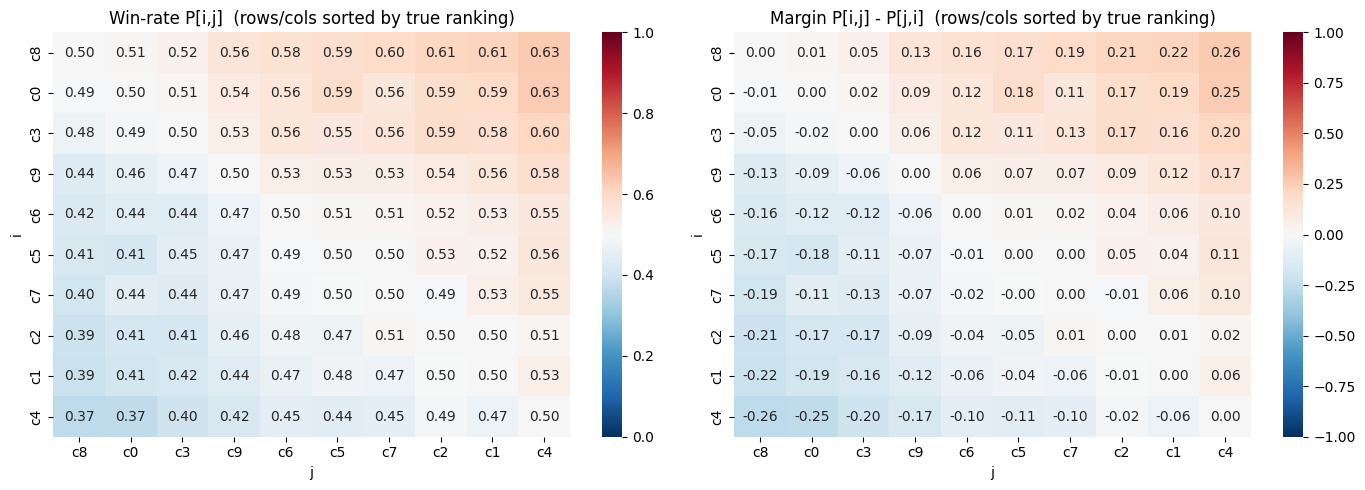

In [27]:
candidate_labels = [f"c{i}" for i in range(M)]
ordered = true_ranking  # sort rows/cols by true ranking for readability

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw win-rate matrix
ax = axes[0]
sns.heatmap(
    P[np.ix_(ordered, ordered)],
    ax=ax, annot=True, fmt=".2f", cmap="RdBu_r", vmin=0, vmax=1,
    xticklabels=[candidate_labels[i] for i in ordered],
    yticklabels=[candidate_labels[i] for i in ordered],
)
ax.set_title("Win-rate P[i,j]  (rows/cols sorted by true ranking)")
ax.set_xlabel("j")
ax.set_ylabel("i")

# margin matrix P - P.T
margin = P - P.T
ax = axes[1]
sns.heatmap(
    margin[np.ix_(ordered, ordered)],
    ax=ax, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
    xticklabels=[candidate_labels[i] for i in ordered],
    yticklabels=[candidate_labels[i] for i in ordered],
)
ax.set_title("Margin P[i,j] - P[j,i]  (rows/cols sorted by true ranking)")
ax.set_xlabel("j")
ax.set_ylabel("i")

plt.tight_layout()
plt.show()

In [28]:
pairs = [(i, j) for i in range(M) for j in range(i + 1, M)]
consistent = sum(
    (avg_utilities[i] > avg_utilities[j]) == (P[i, j] > 0.5)
    for i, j in pairs
)
print(f"Pairs where win-rate agrees with avg-utility order: {consistent}/{len(pairs)}")
print("P:\n", np.round(P, 3))
print("Margin (P - P.T):\n", np.round(margin, 3))

Pairs where win-rate agrees with avg-utility order: 44/45
P:
 [[0.5   0.594 0.586 0.512 0.625 0.589 0.561 0.556 0.493 0.543]
 [0.406 0.5   0.496 0.418 0.529 0.478 0.468 0.471 0.388 0.44 ]
 [0.414 0.504 0.5   0.413 0.511 0.474 0.48  0.506 0.394 0.456]
 [0.488 0.582 0.587 0.5   0.602 0.553 0.561 0.563 0.475 0.53 ]
 [0.375 0.471 0.489 0.398 0.5   0.445 0.448 0.451 0.371 0.417]
 [0.411 0.522 0.526 0.447 0.555 0.5   0.494 0.502 0.414 0.467]
 [0.439 0.532 0.52  0.439 0.552 0.506 0.5   0.51  0.422 0.47 ]
 [0.444 0.529 0.494 0.437 0.549 0.498 0.49  0.5   0.403 0.467]
 [0.507 0.612 0.606 0.525 0.629 0.586 0.578 0.597 0.5   0.564]
 [0.457 0.56  0.544 0.47  0.583 0.533 0.53  0.533 0.436 0.5  ]]
Margin (P - P.T):
 [[ 0.     0.188  0.172  0.023  0.251  0.178  0.122  0.112 -0.015  0.087]
 [-0.188  0.    -0.008 -0.164  0.057 -0.045 -0.063 -0.057 -0.225 -0.121]
 [-0.172  0.008  0.    -0.175  0.021 -0.052 -0.041  0.011 -0.213 -0.088]
 [-0.023  0.164  0.175  0.     0.203  0.107  0.121  0.126 -0.05   0.0

## Rankings and distortions across beta

In [29]:
import sys
sys.path.insert(0, '/home/jennifer/distortion')
from utils_3 import (
    argmax_lottery_from_population_utilities,
    nonzero_max_from_population_utilities,
    leaderboard_dist,
)

In [30]:
def borda_from_P(P, cand_dist):
    """Borda score for each candidate: expected win prob against a cand_dist-weighted opponent."""
    scores = P @ cand_dist  # score[i] = sum_j P[i,j] * cand_dist[j]
    return np.argsort(-scores)


def borda_peeling_from_P(P, cand_dist):
    """Borda with peeling: at each round restrict to remaining candidates, reweight cand_dist."""
    C = P.shape[0]
    remaining = list(range(C))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        P_rem = P[np.ix_(rem, rem)]
        cd_rem = cand_dist[rem] / cand_dist[rem].sum()
        scores = P_rem @ cd_rem  # score[i] = sum_j P[i,j] * cand_dist[j]
        winner_local = int(np.argmax(scores))
        ranking.append(remaining[winner_local])
        remaining.pop(winner_local)
    return np.array(ranking, dtype=int)

In [31]:
betas = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0]
cand_dist = np.ones(M, dtype=float) / M  # uniform: all opponents equally likely

methods = ['borda', 'borda_peeling', 'ml_argmax', 'ml_nonzero']
distortions = {m: [] for m in methods}

for b in betas:
    P_b = win_rate_matrix(utilities, voter_dist, beta=b)

    distortions['borda'].append(
        leaderboard_dist(borda_from_P(P_b, cand_dist), true_ranking, avg_utilities)[0])

    distortions['borda_peeling'].append(
        leaderboard_dist(borda_peeling_from_P(P_b, cand_dist), true_ranking, avg_utilities)[0])

    try:
        _, r = argmax_lottery_from_population_utilities(utilities, voter_dist=voter_dist, beta=b)
        distortions['ml_argmax'].append(leaderboard_dist(r, true_ranking, avg_utilities)[0])
    except RuntimeError:
        distortions['ml_argmax'].append(float('nan'))

    try:
        _, r = nonzero_max_from_population_utilities(utilities, voter_dist=voter_dist, beta=b)
        distortions['ml_nonzero'].append(leaderboard_dist(r, true_ranking, avg_utilities)[0])
    except RuntimeError:
        distortions['ml_nonzero'].append(float('nan'))

for m in methods:
    print(m, np.round(distortions[m], 4))

borda [1.     1.     1.     1.     1.     1.     1.     1.3448 1.3448 1.3448]
borda_peeling [1.     1.     1.3347 1.3347 1.3347 1.3347 1.5134 1.5134 1.5134 1.5134]
ml_argmax [1.     1.     1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.5134]
ml_nonzero [1.     1.     1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.5134]


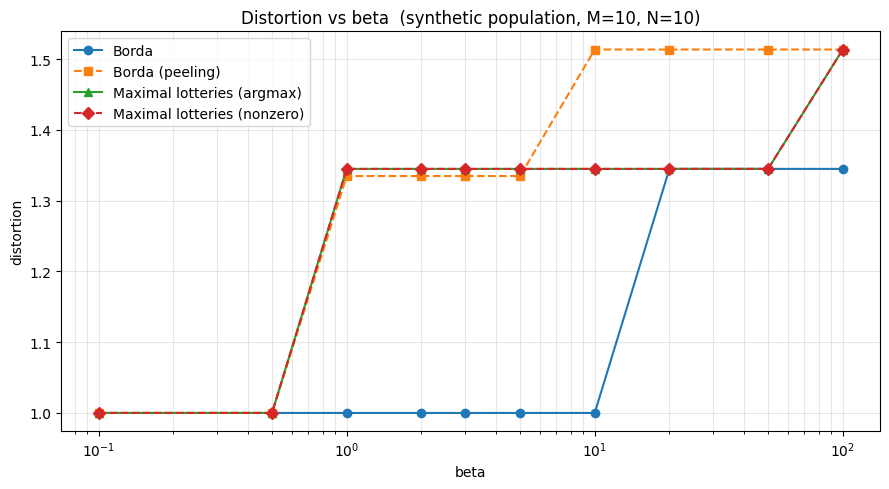

In [32]:
style = {
    'borda':         dict(marker='o', linestyle='-',  label='Borda'),
    'borda_peeling': dict(marker='s', linestyle='--', label='Borda (peeling)'),
    'ml_argmax':     dict(marker='^', linestyle='-',  label='Maximal lotteries (argmax)'),
    'ml_nonzero':    dict(marker='D', linestyle='--', label='Maximal lotteries (nonzero)'),
}

fig, ax = plt.subplots(figsize=(9, 5))
for m, kw in style.items():
    ax.plot(betas, distortions[m], **kw)

ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.set_title(f'Distortion vs beta  (synthetic population, M={M}, N={N})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Same comparison across five additional populations

In [33]:
def compute_distortions(utilities, voter_dist, betas, cand_dist=None):
    V, C = utilities.shape
    avg_utils = voter_dist @ utilities
    true_rank = np.argsort(-avg_utils)
    if cand_dist is None:
        cand_dist = np.ones(C, dtype=float) / C
    out = {m: [] for m in ['borda', 'borda_peeling', 'ml_argmax', 'ml_nonzero']}
    for b in betas:
        P_b = win_rate_matrix(utilities, voter_dist, beta=b)

        out['borda'].append(
            leaderboard_dist(borda_from_P(P_b, cand_dist), true_rank, avg_utils)[0])

        out['borda_peeling'].append(
            leaderboard_dist(borda_peeling_from_P(P_b, cand_dist), true_rank, avg_utils)[0])

        try:
            _, r = argmax_lottery_from_population_utilities(utilities, voter_dist=voter_dist, beta=b)
            out['ml_argmax'].append(leaderboard_dist(r, true_rank, avg_utils)[0])
        except RuntimeError:
            out['ml_argmax'].append(float('nan'))

        try:
            _, r = nonzero_max_from_population_utilities(utilities, voter_dist=voter_dist, beta=b)
            out['ml_nonzero'].append(leaderboard_dist(r, true_rank, avg_utils)[0])
        except RuntimeError:
            out['ml_nonzero'].append(float('nan'))

    return out


extra_seeds = [0, 7, 13, 99, 2024]
all_results = []

for seed in extra_seeds:
    rng_s = np.random.default_rng(seed)
    utils_s = rng_s.standard_normal((N, M))
    vdist_s = np.ones(N, dtype=float) / N
    all_results.append((seed, compute_distortions(utils_s, vdist_s, betas)))
    print(f"seed {seed} done")

seed 0 done
seed 7 done
seed 13 done
seed 99 done
seed 2024 done


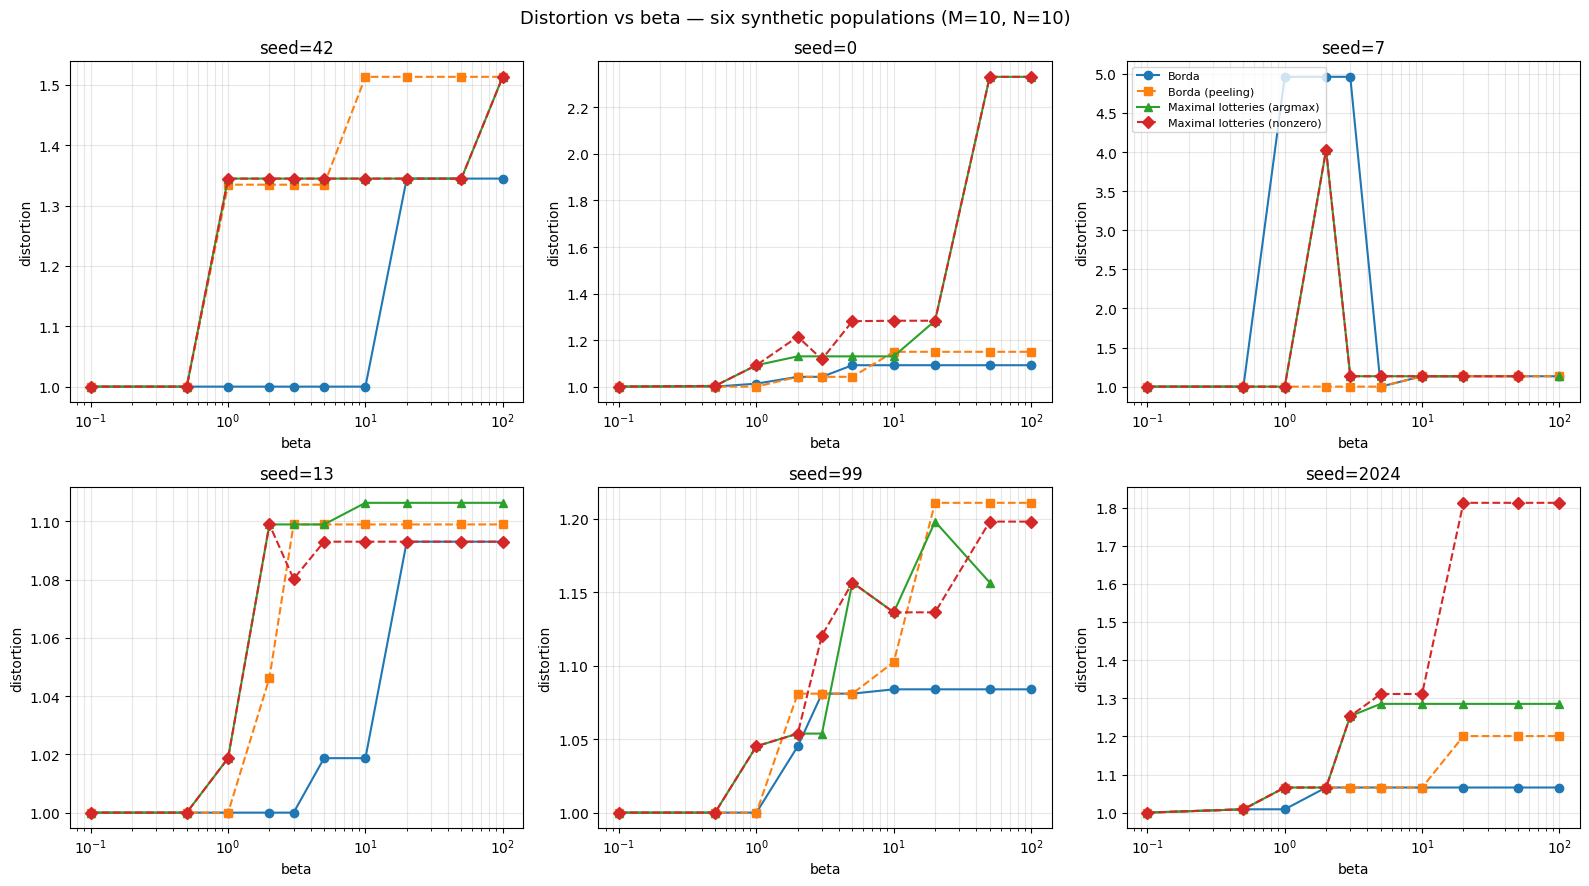

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
axes = axes.flat

# first panel: original seed-42 population
panels = [(42, distortions)] + all_results

for ax, (seed, d) in zip(axes, panels):
    for m, kw in style.items():
        ax.plot(betas, d[m], **kw)
    ax.set_xscale('log')
    ax.set_title(f'seed={seed}')
    ax.set_xlabel('beta')
    ax.set_ylabel('distortion')
    ax.grid(True, which='both', alpha=0.3)

axes[2].legend(loc='upper left', fontsize=8)
fig.suptitle(f'Distortion vs beta — six synthetic populations (M={M}, N={N})', fontsize=13)
plt.tight_layout()
plt.show()

## Averaged distortions over many random populations

Utilities drawn i.i.d. from N(0,1); win-rate matrices computed from utilities via `win_rate_matrix`.

In [35]:
n_populations = 200
M_bulk = 10
N_bulk = 10
betas_bulk = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0]
cand_dist_bulk = np.ones(M_bulk, dtype=float) / M_bulk

rng_bulk = np.random.default_rng(0)
methods = ['borda', 'borda_peeling', 'ml_argmax', 'ml_nonzero']
all_distortions = {m: [] for m in methods}

for pop_idx in range(n_populations):
    utils = rng_bulk.standard_normal((N_bulk, M_bulk))
    vdist = np.ones(N_bulk, dtype=float) / N_bulk
    d = compute_distortions(utils, vdist, betas_bulk, cand_dist=cand_dist_bulk)
    for m in methods:
        all_distortions[m].append(d[m])

mean_dist = {m: np.nanmean(all_distortions[m], axis=0) for m in methods}
std_dist  = {m: np.nanstd(all_distortions[m],  axis=0) for m in methods}

print(f"Averaged over {n_populations} populations (M={M_bulk}, N={N_bulk})")
for m in methods:
    print(f"  {m}: mean distortion range [{mean_dist[m].min():.4f}, {mean_dist[m].max():.4f}]")

Averaged over 200 populations (M=10, N=10)
  borda: mean distortion range [1.0000, 2.2784]
  borda_peeling: mean distortion range [1.0001, 2.2069]
  ml_argmax: mean distortion range [1.0001, 24.8093]
  ml_nonzero: mean distortion range [1.0001, 26.7536]


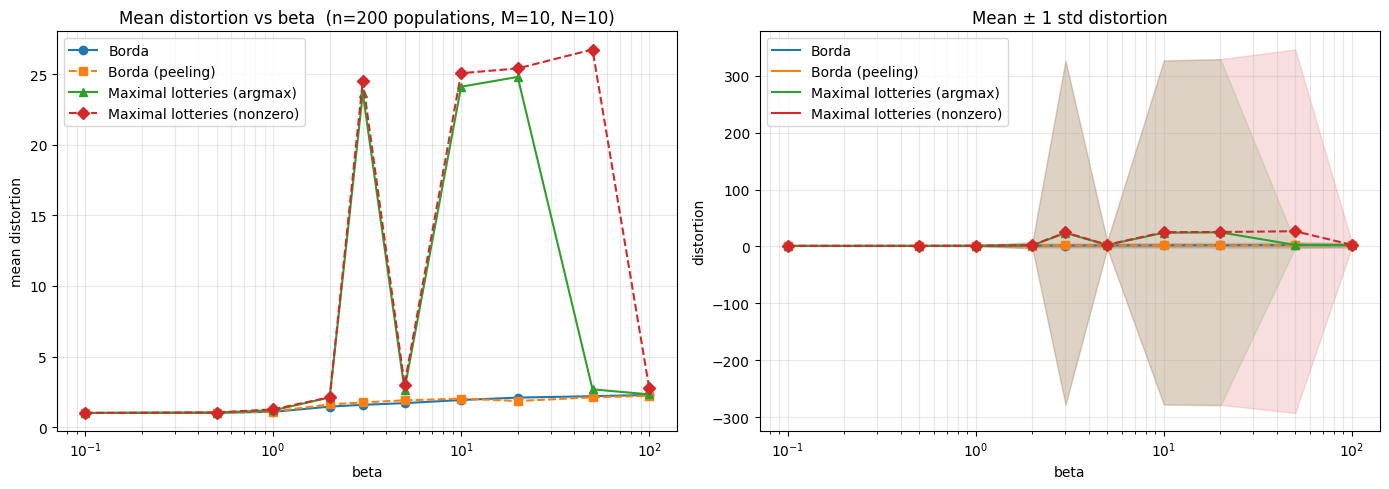

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: mean distortion
ax = axes[0]
for m, kw in style.items():
    ax.plot(betas_bulk, mean_dist[m], **kw)
ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('mean distortion')
ax.set_title(f'Mean distortion vs beta  (n={n_populations} populations, M={M_bulk}, N={N_bulk})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

# right: mean ± 1 std
ax = axes[1]
colors = {'borda': 'C0', 'borda_peeling': 'C1', 'ml_argmax': 'C2', 'ml_nonzero': 'C3'}
for m, kw in style.items():
    c = colors[m]
    ax.plot(betas_bulk, mean_dist[m], color=c, **kw)
    ax.fill_between(
        betas_bulk,
        mean_dist[m] - std_dist[m],
        mean_dist[m] + std_dist[m],
        alpha=0.15, color=c,
    )
ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.set_title('Mean ± 1 std distortion')
ax.legend(handles=[
    plt.Line2D([0], [0], color=colors[m], label=style[m]['label'])
    for m in methods
])
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

### Infinite-sample win-rate matrices

Pre-compute the exact theoretical win-rate matrix P for each (population, beta). Borda and Borda-peeling are applied directly from P; no finite-sample noise.

In [37]:
def distortions_from_P(P_by_beta, avg_utils, betas, cand_dist):
    """Compute borda / borda_peeling distortions given pre-computed win-rate matrices."""
    true_rank = np.argsort(-avg_utils)
    out = {'borda': [], 'borda_peeling': []}
    for b in betas:
        P = P_by_beta[b]
        out['borda'].append(
            leaderboard_dist(borda_from_P(P, cand_dist), true_rank, avg_utils)[0])
        out['borda_peeling'].append(
            leaderboard_dist(borda_peeling_from_P(P, cand_dist), true_rank, avg_utils)[0])
    return out


n_pop = 200
M_inf = 10
N_inf = 10
betas_inf = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0]
cand_dist_inf = np.ones(M_inf, dtype=float) / M_inf

rng_inf = np.random.default_rng(1)
inf_distortions = {'borda': [], 'borda_peeling': []}

for _ in range(n_pop):
    utils = rng_inf.standard_normal((N_inf, M_inf))
    vdist = np.ones(N_inf, dtype=float) / N_inf
    avg_utils = vdist @ utils

    # infinite-sample win-rate matrix for each beta
    P_by_beta = {b: win_rate_matrix(utils, vdist, beta=b) for b in betas_inf}

    d = distortions_from_P(P_by_beta, avg_utils, betas_inf, cand_dist_inf)
    for m in inf_distortions:
        inf_distortions[m].append(d[m])

inf_mean = {m: np.mean(inf_distortions[m], axis=0) for m in inf_distortions}
inf_std  = {m: np.std(inf_distortions[m],  axis=0) for m in inf_distortions}

print(f"Infinite-sample regime, {n_pop} populations (M={M_inf}, N={N_inf})")
for m in inf_distortions:
    print(f"  {m}: {np.round(inf_mean[m], 4)}")

Infinite-sample regime, 200 populations (M=10, N=10)
  borda: [1.     1.0125 1.0831 1.2812 1.4029 1.6838 1.8117 1.9973 2.0235 2.0147]
  borda_peeling: [1.0001 1.0216 1.0972 1.5896 1.8661 1.9732 2.1826 2.8213 2.5125 2.4642]


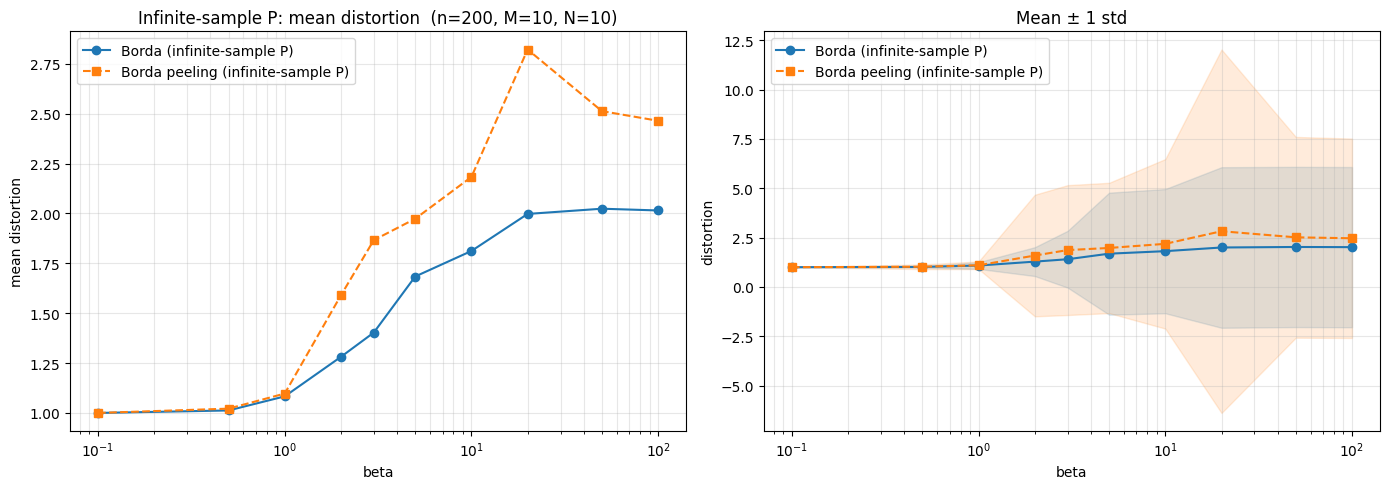

In [38]:
inf_colors = {'borda': 'C0', 'borda_peeling': 'C1'}
inf_style  = {
    'borda':         dict(marker='o', linestyle='-',  label='Borda (infinite-sample P)'),
    'borda_peeling': dict(marker='s', linestyle='--', label='Borda peeling (infinite-sample P)'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for m in inf_distortions:
    ax.plot(betas_inf, inf_mean[m], color=inf_colors[m], **inf_style[m])
ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('mean distortion')
ax.set_title(f'Infinite-sample P: mean distortion  (n={n_pop}, M={M_inf}, N={N_inf})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
for m in inf_distortions:
    c = inf_colors[m]
    ax.plot(betas_inf, inf_mean[m], color=c, **inf_style[m])
    ax.fill_between(
        betas_inf,
        inf_mean[m] - inf_std[m],
        inf_mean[m] + inf_std[m],
        alpha=0.15, color=c,
    )
ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.set_title('Mean ± 1 std')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

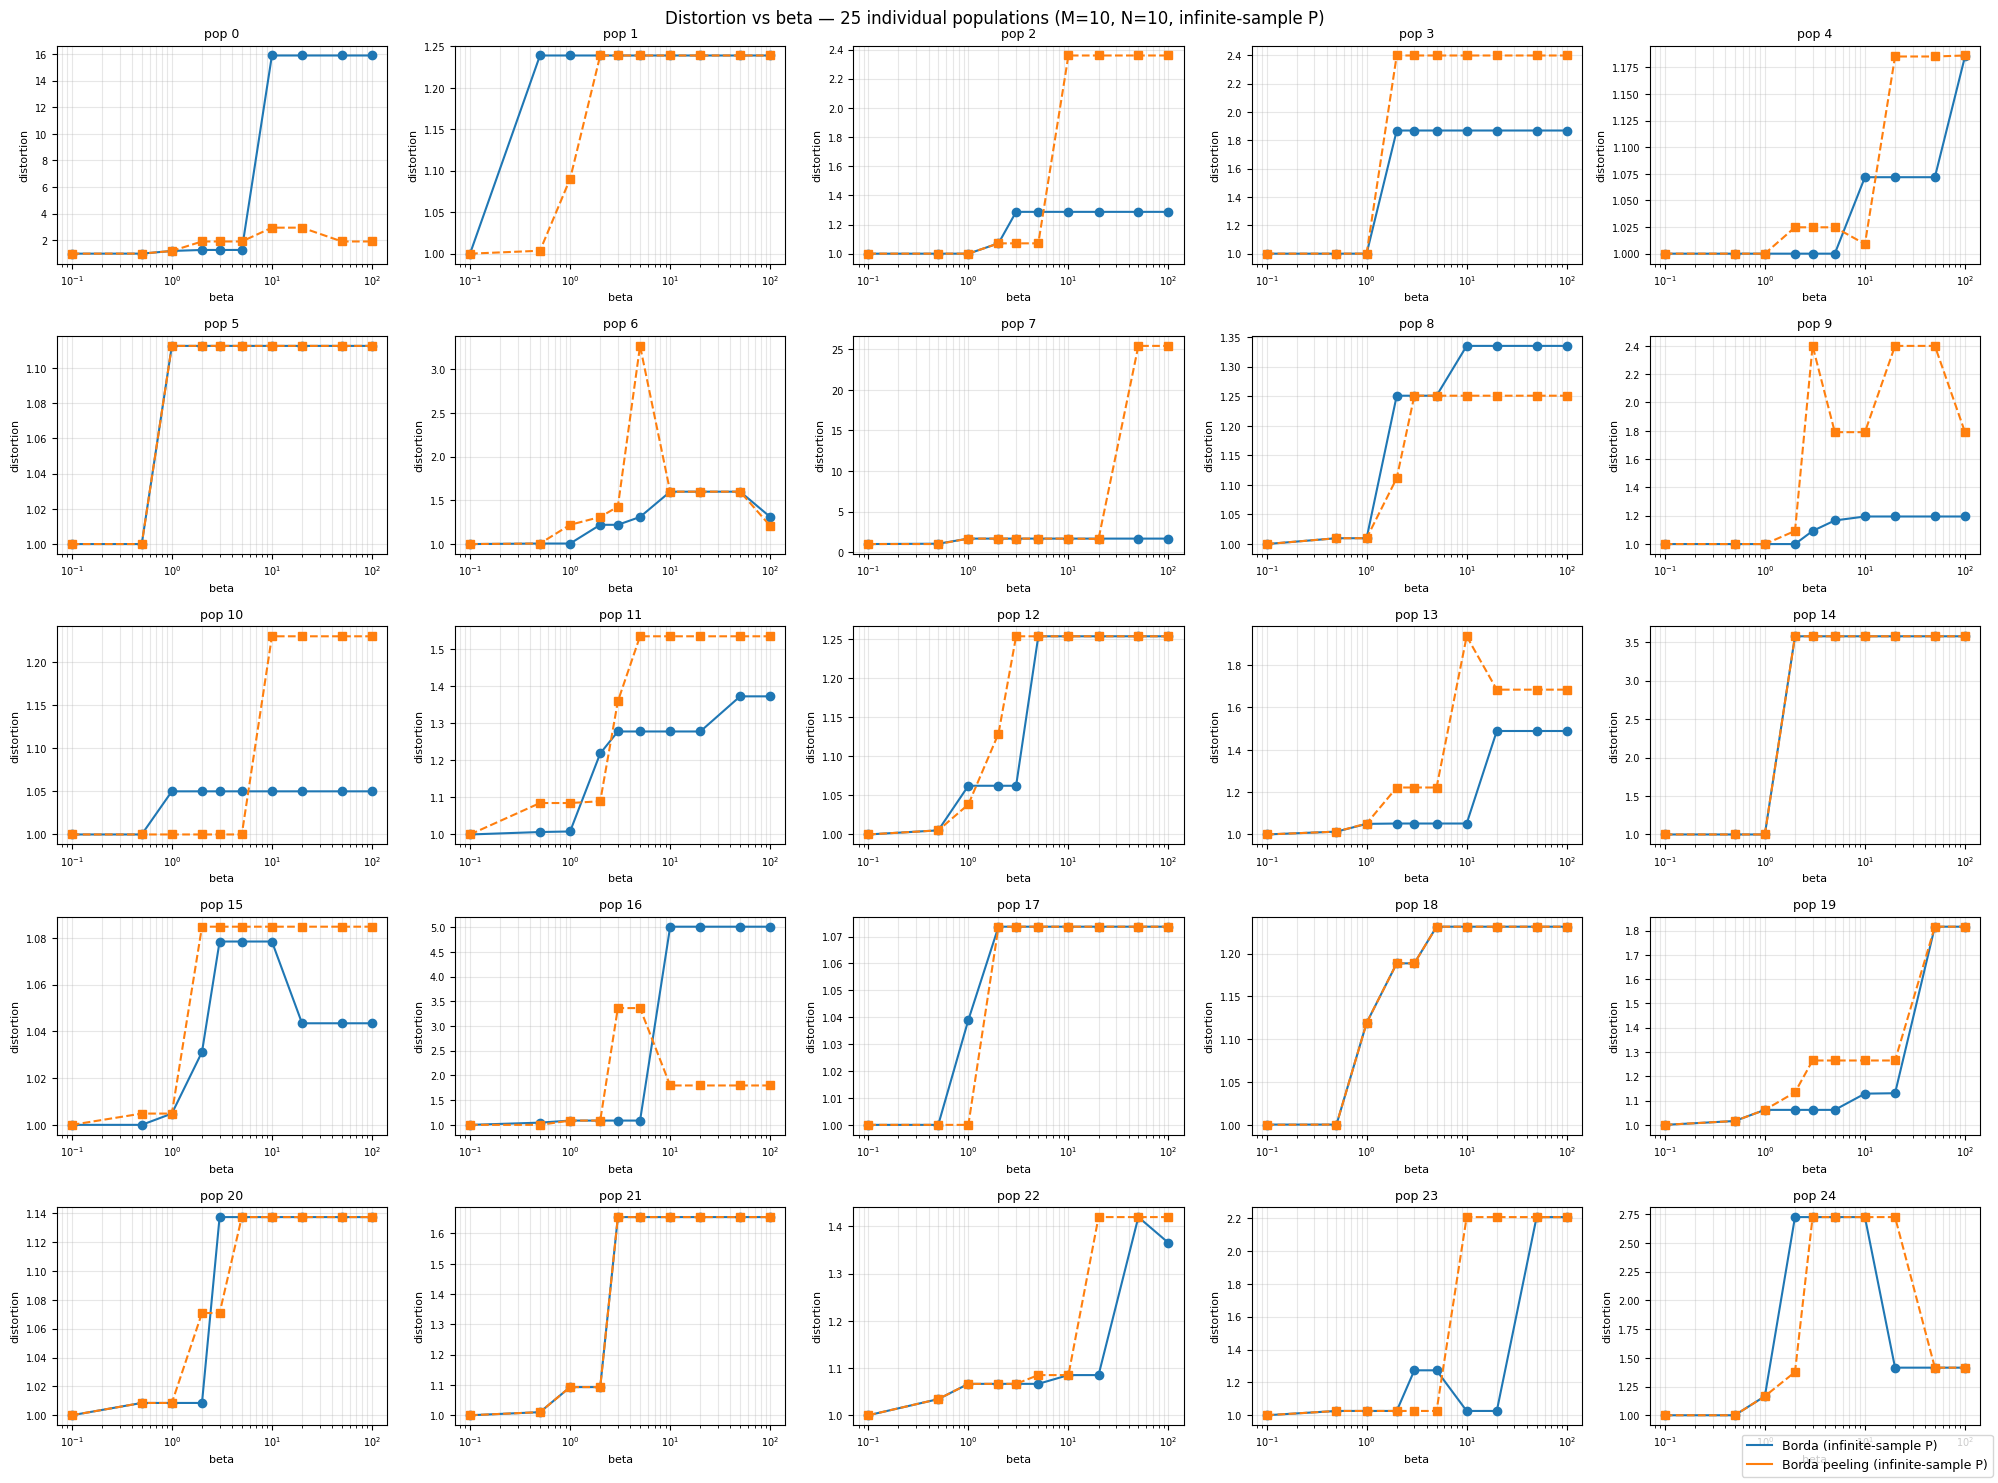

In [39]:
n_show = 25  # number of populations to display; adjust as needed
ncols = 5
nrows = (n_show + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=False)
axes = axes.flat

for pop_idx in range(n_show):
    ax = axes[pop_idx]
    for m in inf_distortions:
        ax.plot(betas_inf, inf_distortions[m][pop_idx], color=inf_colors[m], **inf_style[m])
    ax.set_xscale('log')
    ax.set_title(f'pop {pop_idx}', fontsize=9)
    ax.set_xlabel('beta', fontsize=8)
    ax.set_ylabel('distortion', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, which='both', alpha=0.3)

# hide unused axes
for ax in list(axes)[n_show:]:
    ax.set_visible(False)

handles = [
    plt.Line2D([0], [0], color=inf_colors[m], label=inf_style[m]['label'])
    for m in inf_distortions
]
fig.legend(handles=handles, loc='lower right', fontsize=9)
fig.suptitle(
    f'Distortion vs beta — {n_show} individual populations (M={M_inf}, N={N_inf}, infinite-sample P)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

### Same plots with a fixed weight set

Replace the supremum distortion with a weighted leaderboard distortion using a fixed monotonically decreasing weight vector.

In [40]:
def leaderboard_dist_w(ranking, true_ranking, avg_utils, w):
    avg_utils = avg_utils - avg_utils.min()  # shift to non-negative so ratio is well-defined
    ranking_utils = avg_utils[np.asarray(ranking)]
    true_ranking_utils = avg_utils[np.asarray(true_ranking)]
    return (true_ranking_utils * w).sum() / (ranking_utils * w).sum(), None


def distortions_from_P_w(P_by_beta, avg_utils, betas, cand_dist, w):
    true_rank = np.argsort(-avg_utils)
    out = {'borda': [], 'borda_peeling': []}
    for b in betas:
        P = P_by_beta[b]
        out['borda'].append(
            leaderboard_dist_w(borda_from_P(P, cand_dist), true_rank, avg_utils, w)[0])
        out['borda_peeling'].append(
            leaderboard_dist_w(borda_peeling_from_P(P, cand_dist), true_rank, avg_utils, w)[0])
    return out


w = 1 / (1.1 ** np.arange(M_inf))

rng_w = np.random.default_rng(1)  # same seed as infinite-sample run above
inf_distortions_w = {'borda': [], 'borda_peeling': []}

for _ in range(n_pop):
    utils = rng_w.standard_normal((N_inf, M_inf))
    vdist = np.ones(N_inf, dtype=float) / N_inf
    avg_utils = vdist @ utils

    P_by_beta = {b: win_rate_matrix(utils, vdist, beta=b) for b in betas_inf}

    d = distortions_from_P_w(P_by_beta, avg_utils, betas_inf, cand_dist_inf, w)
    for m in inf_distortions_w:
        inf_distortions_w[m].append(d[m])

inf_mean_w = {m: np.mean(inf_distortions_w[m], axis=0) for m in inf_distortions_w}
inf_std_w  = {m: np.std(inf_distortions_w[m],  axis=0) for m in inf_distortions_w}

print(f"Fixed weight set, {n_pop} populations (M={M_inf}, N={N_inf})")
for m in inf_distortions_w:
    print(f"  {m}: {np.round(inf_mean_w[m], 4)}")

Fixed weight set, 200 populations (M=10, N=10)
  borda: [1.     1.0001 1.0012 1.0041 1.0057 1.0076 1.0088 1.0095 1.0101 1.01  ]
  borda_peeling: [1.     1.0002 1.0014 1.0053 1.0076 1.0102 1.0122 1.0133 1.0141 1.014 ]


In [41]:
w

array([1.        , 0.90909091, 0.82644628, 0.7513148 , 0.68301346,
       0.62092132, 0.56447393, 0.51315812, 0.46650738, 0.42409762])

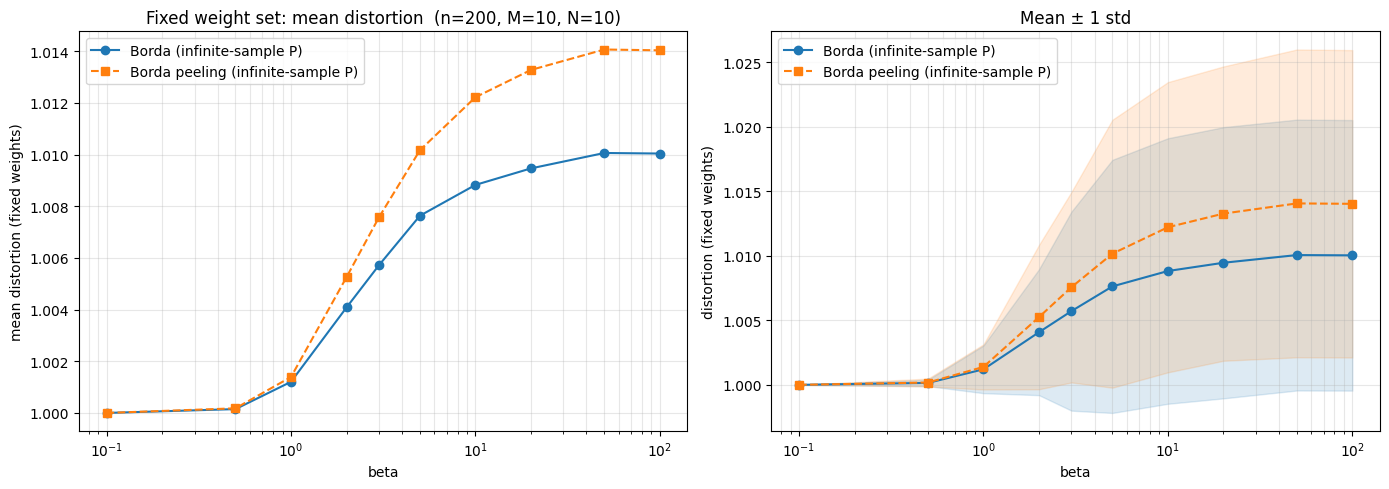

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for m in inf_distortions_w:
    ax.plot(betas_inf, inf_mean_w[m], color=inf_colors[m], **inf_style[m])
ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('mean distortion (fixed weights)')
ax.set_title(f'Fixed weight set: mean distortion  (n={n_pop}, M={M_inf}, N={N_inf})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
for m in inf_distortions_w:
    c = inf_colors[m]
    ax.plot(betas_inf, inf_mean_w[m], color=c, **inf_style[m])
    ax.fill_between(
        betas_inf,
        inf_mean_w[m] - inf_std_w[m],
        inf_mean_w[m] + inf_std_w[m],
        alpha=0.15, color=c,
    )
ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion (fixed weights)')
ax.set_title('Mean ± 1 std')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

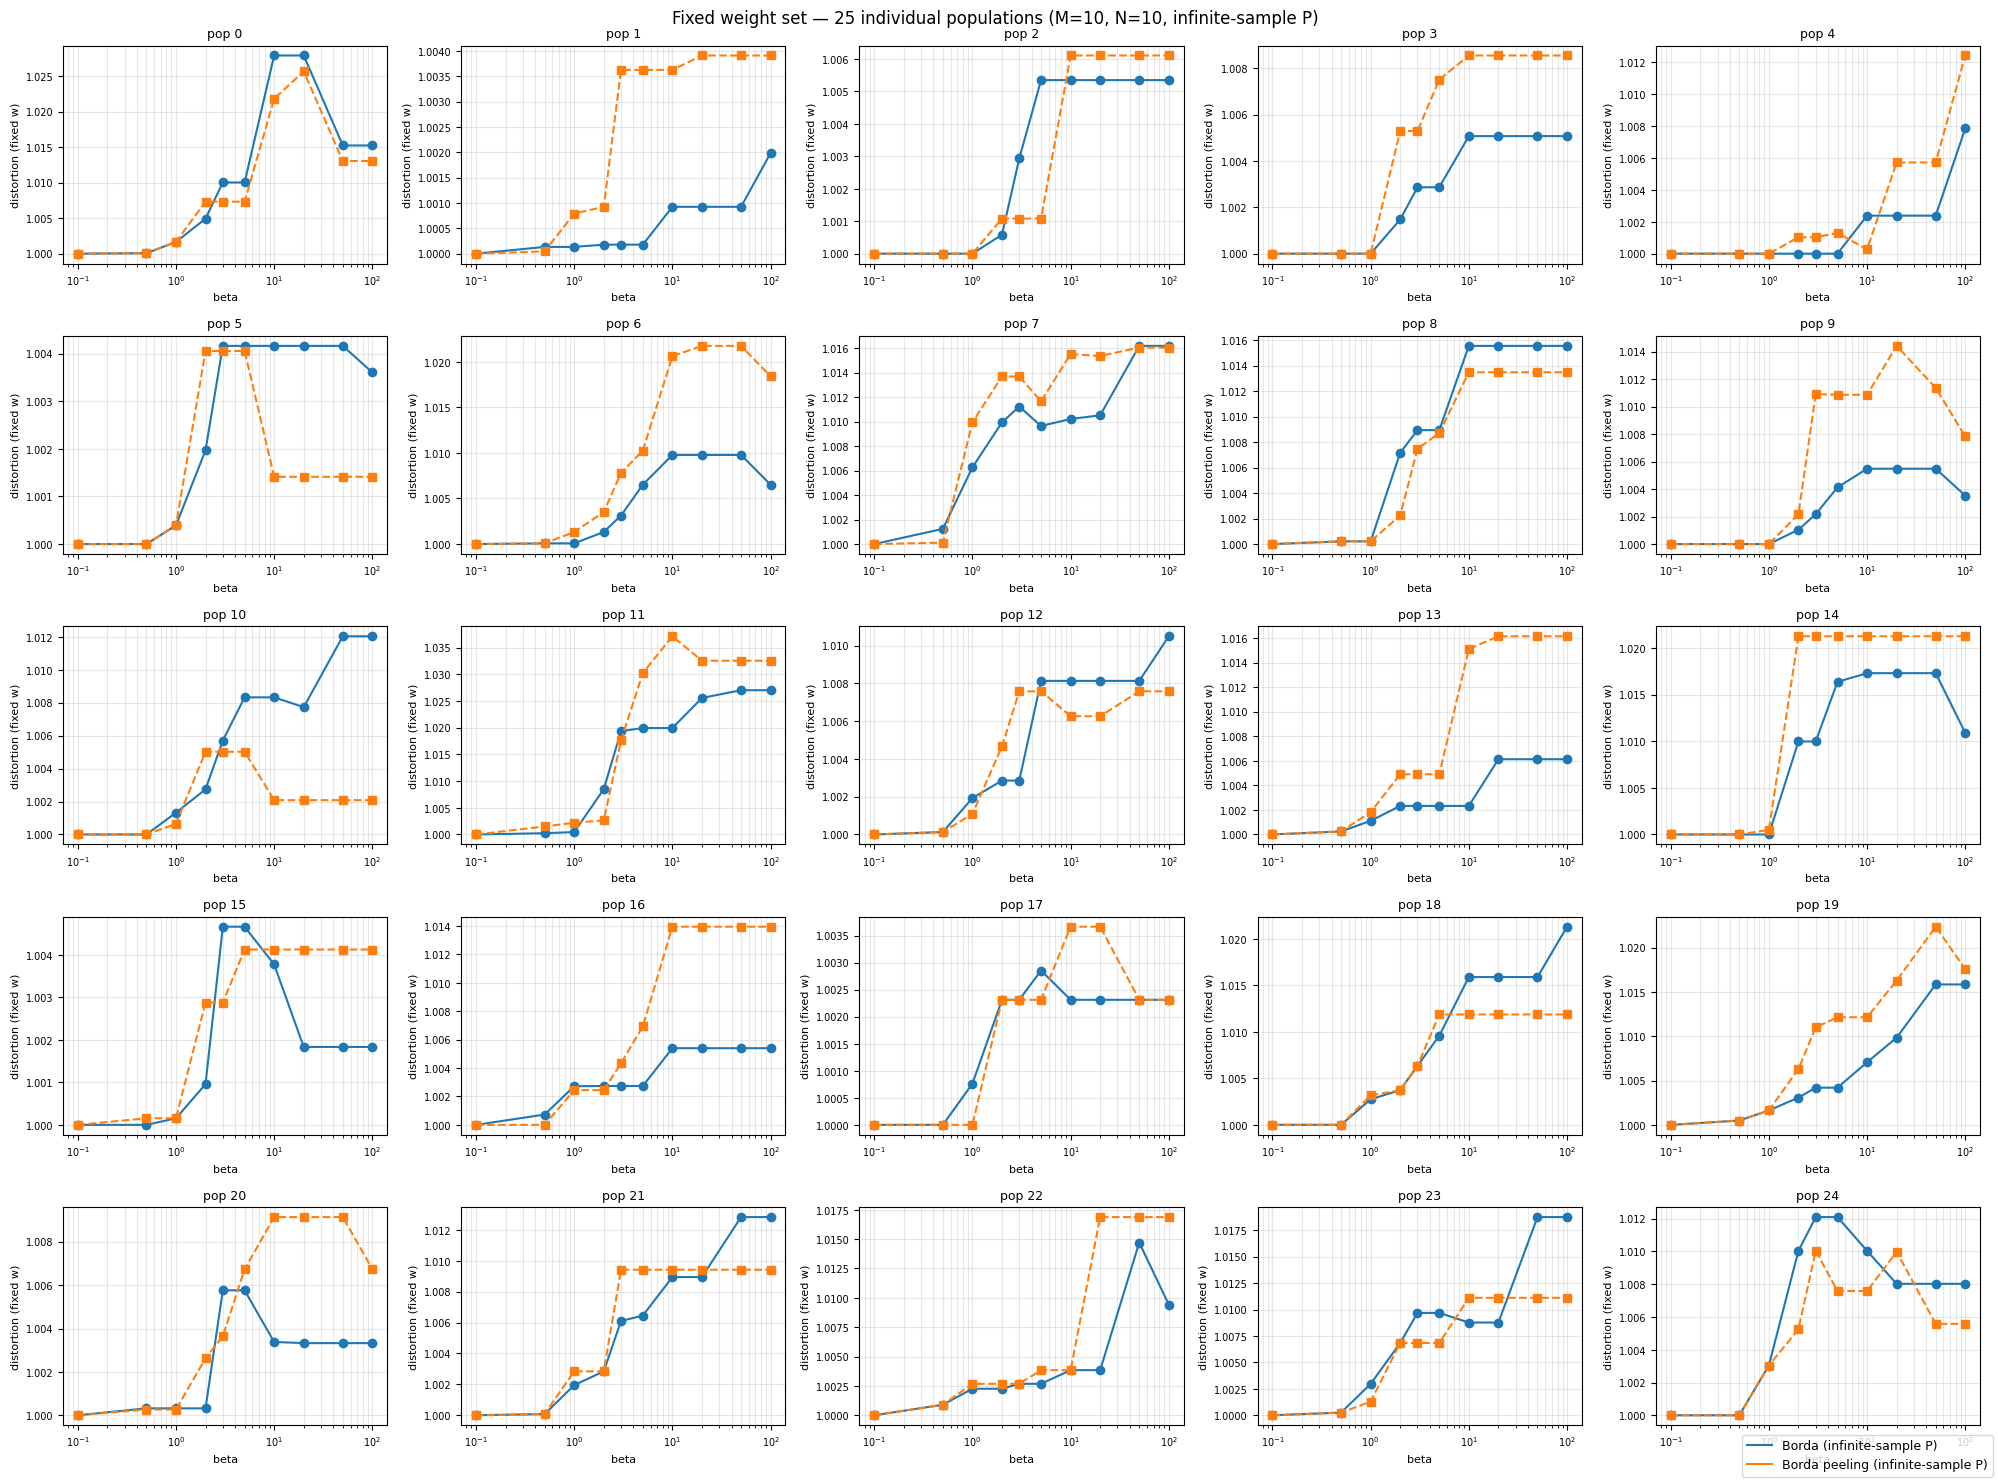

In [43]:
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=False)
axes = axes.flat

for pop_idx in range(n_show):
    ax = axes[pop_idx]
    for m in inf_distortions_w:
        ax.plot(betas_inf, inf_distortions_w[m][pop_idx], color=inf_colors[m], **inf_style[m])
    ax.set_xscale('log')
    ax.set_title(f'pop {pop_idx}', fontsize=9)
    ax.set_xlabel('beta', fontsize=8)
    ax.set_ylabel('distortion (fixed w)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, which='both', alpha=0.3)

for ax in list(axes)[n_show:]:
    ax.set_visible(False)

fig.legend(handles=handles, loc='lower right', fontsize=9)
fig.suptitle(
    f'Fixed weight set — {n_show} individual populations (M={M_inf}, N={N_inf}, infinite-sample P)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Diagnosing high-distortion populations

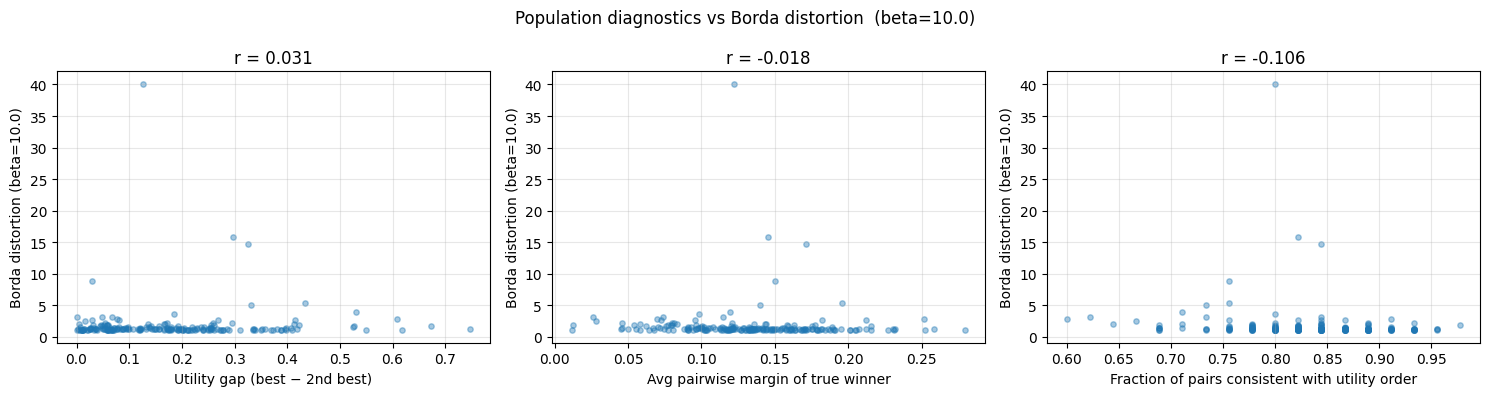

In [44]:
# Re-generate the same 200 populations (seed=1, matching the infinite-sample run)
# and record diagnostic quantities for each.
rng_diag = np.random.default_rng(1)
beta_diag = 10.0
beta_idx  = betas_inf.index(beta_diag)

diagnostics = []

for _ in range(n_pop):
    utils = rng_diag.standard_normal((N_inf, M_inf))
    vdist = np.ones(N_inf, dtype=float) / N_inf
    avg_utils = vdist @ utils
    true_rank = np.argsort(-avg_utils)

    P = win_rate_matrix(utils, vdist, beta=beta_diag)

    # gap in avg utility between the best and second-best candidate
    sorted_utils = avg_utils[true_rank]
    utility_gap = sorted_utils[0] - sorted_utils[1]

    # avg pairwise margin of the true winner against the rest
    best = true_rank[0]
    win_margin_of_best = P[best].mean() - 0.5

    # fraction of (i,j) pairs where pairwise order agrees with utility order
    pairs_consistent = np.mean([
        (avg_utils[i] > avg_utils[j]) == (P[i, j] > 0.5)
        for i in range(M_inf) for j in range(M_inf) if i != j
    ])

    diagnostics.append({
        'utility_gap':        utility_gap,
        'win_margin_of_best': win_margin_of_best,
        'pairs_consistent':   pairs_consistent,
    })

distortion_at_beta = np.array(inf_distortions['borda'])[:, beta_idx]

diag_keys   = ['utility_gap', 'win_margin_of_best', 'pairs_consistent']
diag_labels = [
    'Utility gap (best − 2nd best)',
    'Avg pairwise margin of true winner',
    'Fraction of pairs consistent with utility order',
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, label in zip(axes, diag_keys, diag_labels):
    x = np.array([d[key] for d in diagnostics])
    ax.scatter(x, distortion_at_beta, alpha=0.4, s=15)
    r = np.corrcoef(x, distortion_at_beta)[0, 1]
    ax.set_xlabel(label)
    ax.set_ylabel(f'Borda distortion (beta={beta_diag})')
    ax.set_title(f'r = {r:.3f}')
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Population diagnostics vs Borda distortion  (beta={beta_diag})', fontsize=12)
plt.tight_layout()
plt.show()

Kept 178/200 populations  (removed 22 outliers above 2.073)


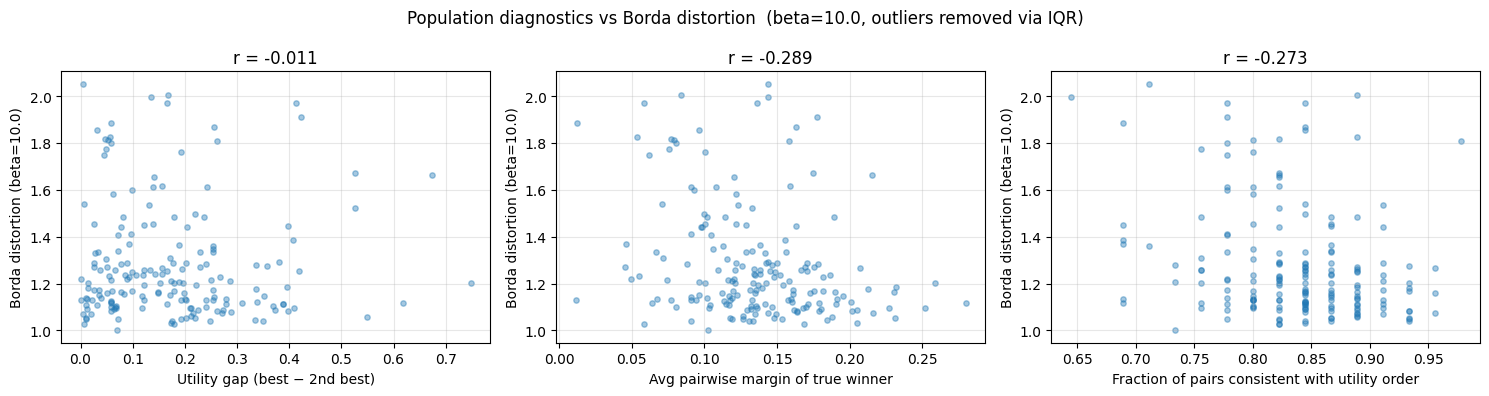

In [45]:
q1, q3 = np.percentile(distortion_at_beta, [25, 75])
iqr = q3 - q1
mask = distortion_at_beta <= q3 + 1.5 * iqr

print(f"Kept {mask.sum()}/{len(mask)} populations  "
      f"(removed {(~mask).sum()} outliers above {q3 + 1.5 * iqr:.3f})")

dist_clean = distortion_at_beta[mask]
diag_clean = [diagnostics[i] for i, keep in enumerate(mask) if keep]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, label in zip(axes, diag_keys, diag_labels):
    x = np.array([d[key] for d in diag_clean])
    ax.scatter(x, dist_clean, alpha=0.4, s=15)
    r = np.corrcoef(x, dist_clean)[0, 1]
    ax.set_xlabel(label)
    ax.set_ylabel(f'Borda distortion (beta={beta_diag})')
    ax.set_title(f'r = {r:.3f}')
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f'Population diagnostics vs Borda distortion  (beta={beta_diag}, outliers removed via IQR)',
    fontsize=12,
)
plt.tight_layout()
plt.show()